In [1]:
# 데이터 불러오기

import pandas as pd
import numpy as np

path = '/content/drive/MyDrive/Colab Notebooks/wine.csv'
df = pd.read_csv(path)

In [2]:
# 데이터 출력해서 확인
df.head()

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [3]:
#label, feature 데이터 입력하

y=df['Wine']

Y = pd.get_dummies(y).values # 원-핫 인코딩, 숫자 크기 의미 제거

X=df.drop('Wine',axis=1)

In [4]:
y.value_counts()
X.head()

,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [5]:
# numpy 변환
X = X.values # 엑셀 형태 → 숫자 배열로 변환하기 위해 사

# 정규화 (데이터를 비슷한 범위로 맞추는 작업)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.25, random_state=0
)

In [7]:
from tensorflow.keras import layers, models
# 층(layer)을 순서대로 쌓는 모델, 입력 → 은닉층 → 출력층으로 일직선 구조

model = models.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X.shape[1],)), # 첫 번째 층 (입력층 + 은닉층),
    # 뉴런(노드) 64개, 입력 데이터의 컬럼 개수, activation="relu" <- 활성화 함수
    layers.Dropout(0.3), # 30% 뉴런을 랜덤으로 off > 과적합 방지
    layers.Dense(32, activation="relu"),# 두 번째 은닉층, 뉴런을 64 → 32로 줄이면서 중요한 정보만 남김
    layers.Dense(Y.shape[1], activation="softmax") # 출력층
    # Y.shape[1] = 클래스 개수, softmax = 확률로 변환
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


* 과적합(Overfitting)은 모델이 학습 데이터에만 과도하게 맞춰져 실제 데이터(검증 데이터)에 대한 일반화 능력이 떨어지는 현상

In [8]:
# 컴파일
model.compile(
    optimizer="adam", # 가중치 업데이트 방법, 자동으로 학습률 조정
    loss="categorical_crossentropy", # 손실 함수, “정답 vs 예측 확률 차이”
    metrics=["accuracy"] # 정확도 측정
)

In [9]:
# 모델학습
history = model.fit(
    X_train, y_train,
    validation_split=0.2, # 학습 데이터 중 20%를 검증용으로 사용
    epochs=50, # 전체 데이터를 50번 반복 학습
    batch_size=16, # 한 번에 16개씩 학습
    verbose=1 # 학습 과정 출력
)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.4623 - loss: 1.0741 - val_accuracy: 0.6296 - val_loss: 0.9806
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6415 - loss: 0.9421 - val_accuracy: 0.7037 - val_loss: 0.8508
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6981 - loss: 0.8320 - val_accuracy: 0.7778 - val_loss: 0.7468
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8113 - loss: 0.6807 - val_accuracy: 0.8148 - val_loss: 0.6570
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8019 - loss: 0.6258 - val_accuracy: 0.8148 - val_loss: 0.5793
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8868 - loss: 0.5194 - val_accuracy: 0.8148 - val_loss: 0.5101
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8868 - loss: 0.4690 - val_accuracy: 0.8148 - val_loss: 0.4473
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9434 - loss: 0.3701 - val_accuracy: 0.8519 - val_loss: 0.3917
Epoch 

In [10]:

y_pred = model.predict(X_test) # 결과 = 확률

y_test_class = np.argmax(y_test,axis=1) # 원-핫 → 숫자
y_pred_class = np.argmax(y_pred,axis=1) # 확률 → 예측 클래스
# 예시 =>
# np.argmax([0,0,1]) → 2
# np.argmax([0.1,0.2,0.7]) → 2

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


In [11]:
# 그래프 그리기용 데이터 저장
loss = history.history['loss']
val_loss = history.history['val_loss']
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']


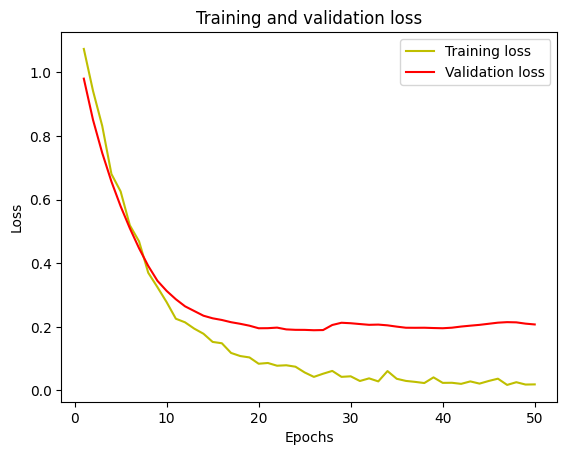

In [12]:
# 학습 과정에서 손실(loss)이 어떻게 변하는지 시각화

import matplotlib.pyplot as plt
import seaborn as sns

loss = history.history['loss'] # loss = 훈련 데이터 오차 /
val_loss = history.history['val_loss'] # val_loss = 검증 데이터 오차
# history는 model.fit() 결과
epochs = range(1, len(loss) + 1) # x축 만들기

plt.plot(epochs, loss, 'y', label='Training loss') # 훈련 데이터 손실
# x축: epoch y축: loss 'y': 노란색
plt.plot(epochs, val_loss, 'r', label='Validation loss') # 검증 데이터 손실
# 'r': 빨간색
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


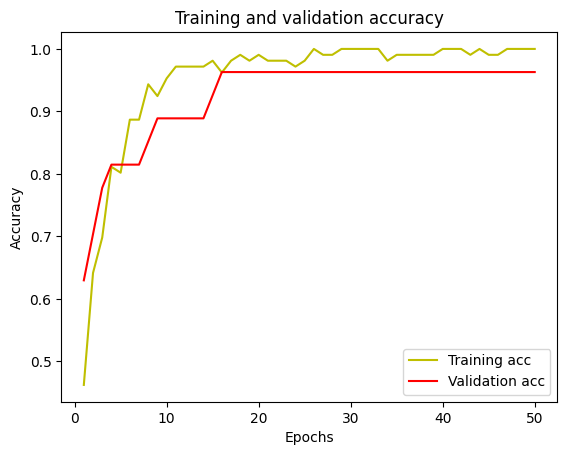

In [13]:
acc = history.history['accuracy'] # 훈련 데이터 정확도
val_acc = history.history['val_accuracy'] # 검증 데이터 정확도
plt.plot(epochs, acc, 'y', label='Training acc') # 훈련 정확도 (노란색)
plt.plot(epochs, val_acc, 'r', label='Validation acc') # 검증 정확도 (빨간색)
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [14]:

from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test_class,y_pred_class))
print(confusion_matrix(y_test_class,y_pred_class))

              precision    recall  f1-score   support

           0       0.88      0.94      0.91        16
           1       0.95      0.86      0.90        21
           2       0.89      1.00      0.94         8

    accuracy                           0.91        45
   macro avg       0.91      0.93      0.92        45
weighted avg       0.91      0.91      0.91        45

[[15  1  0]
 [ 2 18  1]
 [ 0  0  8]]
